<a href="https://colab.research.google.com/github/Jingxian12/movie-recommender-system/blob/main/notebook/Movie_Recommender_System_(PART_B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<div align = center > TITLE : MOVIE RECOMMENDER SYSTEM**</div>


# **PART B : MODELING**

**Summary:**

I performed the development of an end-to-end Movie Recommendation System that integrates three distinct architectural approaches: **Collaborative Filtering, Content-Based Filtering, and Advanced NLP Semantic Search**.

- Using the `MovieLens-100k dataset`, the Collaborative Filtering engine implements **Item-Based, SVD, and Bayesian Personalized Ranking (BPR) models**, cross-evaluating their performance using Top-K metrics including `Precision@K`, `Recall@K`, `HitRate@K`, and `NDCG@K`.
- The Content-Based Filtering pipeline leverages an ETL process that unifies `TMDB API data and Kaggle datasets`, utilizing **TF-IDF vectorization** alongside strict algorithmic sanity checks.

- To maximize user query accuracy, the NLP-Based Filtering engine introduces a hybrid search experience, utilizing a **Sentence-BERT (SBERT)** `Bi-Encoder` for swift vector retrieval and a `Cross-Encoder` model to deeply re-rank candidate results for complex natural language queries.

For deployment, I hosted these three filtering engines on **`Streamlit Community Cloud`**, creating an interactive user interface that allows seamless exploration and real-time comparison of the different recommendation algorithms.





### **Import Necessary Libraries**

In [ ]:
!pip install scikit-surprise
!pip install "numpy<2.0"
!pip install implicit scipy

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import pickle
import gzip

In [ ]:
print(np.__version__)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## **Phase 1 : Correlative Filtering**

### **A) Load Datasets**

#### **MovieLens and Ratings**

In [ ]:
movieLens = pd.read_csv('/content/drive/MyDrive/dataset/movie/API/preprocess_dataset/movieLens.csv')
display(movieLens.head())
print()
print(movieLens.info())
print(movieLens.shape)

In [ ]:
movieLens.isna().sum()

In [ ]:
ratings = pd.read_csv('/content/drive/MyDrive/dataset/movie/API/preprocess_dataset/ratings.csv')
ratings.head()

#### **Merge Dataset**

In [ ]:
merged_df = pd.merge(ratings, movieLens, on='movieId')
display(merged_df.head())
print()
print(merged_df.info())
print(merged_df.shape)

In [ ]:
merged_df.isna().sum()

### **B) EDA**

#### 1. Rating Distribution

In [ ]:
sns.countplot(x="rating", data=merged_df)
plt.title("Rating Distribution")
plt.show()

Graph
- The most frequent rating is 4.0, which has the highest count.
- Ratings of 3.0 and 5.0 also have high frequencies, showing that most users tend to give positive feedback.
- Lower ratings such as 0.5, 1.0, and 1.5 are very rare.

#### 2. Most rated movies

In [ ]:
top_movies = merged_df.groupby("title").size().sort_values(ascending=False).head(10)
top_movies

From Table, the values is represent how many user rate the movie.
- Forrest Gump (1994) → 329 ratings
- Shawshank Redemption → 317 ratings
-  Pulp Fiction → 307 ratings

P.S. But does not mean that these are the highest rated movies, It just mean many people rated this movie

#### 3. Average rating per movie




In [ ]:
movie_stats = merged_df.groupby("title").agg({
    "rating": ["mean", "count"]
})

movie_stats.columns = ["mean_rating", "num_ratings"]
movie_stats = movie_stats.sort_values("num_ratings", ascending=False)

movie_stats.head()

The most-rated movies all have average ratings above 4.0, meaning:
- users generally liked these movies
- popularity and satisfaction are both high

In [ ]:
sns.scatterplot(
    x="num_ratings",
    y="mean_rating",
    data=movie_stats
)
plt.title("Average Rating vs Number of Ratings")
plt.show()

The scatter plot shows that movies with a higher number of ratings generally maintain average ratings above 3.5. While movies with fewer ratings exhibit large variability in average scores, highly rated movies with many ratings appear more stable and reliable. This suggests that popular movies in the dataset are generally well-received by users.

#### 4. Distribution of Ratings by Media Type

In [ ]:
print("--- Original Media Type Counts ---")
print(merged_df["media_type"].value_counts(dropna=False))

plt.figure(figsize=(6, 4))
sns.countplot(data=merged_df, x="media_type", hue="media_type", palette="pastel", legend=False)
plt.title("Distribution of Ratings: Movies vs TV Shows")
plt.xlabel("Media Type")
plt.ylabel("Number of Ratings")
plt.show()

In [ ]:
merged_df = merged_df[merged_df["media_type"] != "tv"]

TV shows were removed because they account for less than 0.2% of the dataset and present TMDB ID collision risks, as TMDB manages movies and TV shows via separate endpoint paths which can cause duplicate IDs in a unified movie recommendation matrix

In [ ]:
duplicates = merged_df[merged_df.duplicated(subset=['userId', 'movieId'], keep=False)]
print("This row is causing the mismatch:")
print(duplicates[['userId', 'movieId', 'rating']])

In [ ]:
merged_df = merged_df.drop_duplicates(subset=['userId', 'movieId'])
merged_df.shape

#### 5. Sparsity Analysis



Sparsity analysis refers to analyzing:
- How many missing values exist in the user–movie matrix
- In recommendation systems, sparsity occurs because most users interact with only a **small number of items**, leaving many empty cells in the matrix.

In [ ]:
user_movie_matrix_eda = merged_df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

In [ ]:
user_movie_matrix_eda.shape

In [ ]:
num_ratings = user_movie_matrix_eda.count().sum()

total_possible = (
    user_movie_matrix_eda.shape[0] *
    user_movie_matrix_eda.shape[1]
)

sparsity = 1 - (num_ratings / total_possible)
print("Number of Ratings :",num_ratings)
print("Total possible ratings:",total_possible)
print()
print(f"Sparsity: {sparsity:.2%}")

A sparsity value of 98.29% indicates that the user–movie matrix is highly sparse, meaning that most users rated only a very small number of movies.

- 98.29% of the user–movie matrix is **empty** (missing ratings).

The high sparsity may reduce similarity accuracy for less-rated movies.
- Therefore, advanced techniques such as `SVD` or `matrix factorization` may provide better performance in handling sparse recommendation data.

We will try **memory-based(item-based filtering)** and **model-based(matrix factorization)**, and compare the evaluation metrics.

#### - Remove unnecessary columns

In [ ]:
merged_df.info()

In [ ]:
merged_df = merged_df.drop(columns=["timestamp","title","genres","media_type"])
merged_df.head()

In [ ]:
merged_df.shape

In [ ]:
# merged_df.to_csv("ratings.csv", index=False)

# # Save files to local computer
# from google.colab import files
# files.download("ratings.csv")

### **C) Set a threshold for movie and ratings**

In [ ]:
threshold_df = merged_df.copy()

In [ ]:
threshold_df.shape

In [ ]:
# 1. First, apply the Global Filter to keep ONLY liked movies (ratings >= 3.5)
threshold_df = threshold_df[threshold_df["rating"] >= 3.5]

# Remove inactive users and unpopular movies
min_movie_ratings = 10
min_user_ratings = 25

# Filter movies
movie_counts = threshold_df['movieId'].value_counts()
valid_movies = movie_counts[movie_counts >= min_movie_ratings].index

# Filter users
user_counts = threshold_df['userId'].value_counts()
valid_users = user_counts[user_counts >= min_user_ratings].index

# Clean dataset
ratings_clean = threshold_df[
    (threshold_df['movieId'].isin(valid_movies)) &
    (threshold_df['userId'].isin(valid_users))
]
print("Cleaned Dataset Shape:", ratings_clean.shape)

# Print the number of unique users and movies
num_users = ratings_clean['userId'].nunique()
num_movies = ratings_clean['movieId'].nunique()

print(f"Number of unique users: {num_users}")
print(f"Number of unique movies: {num_movies}")

In [ ]:
display(ratings_clean.head())

The cleaned dataset contains **44,579 reviews**, where every included user has rated **at least 25 movies with 3.5 or above**,  and every included **movie** has received **at least 10 ratings.**

### **D) Per-user Leave-P-Out Split**
- The dataset was split using a stratified per-user `Leave-5-Out method`. For each user profile, exactly 5 randomly selected movie ratings were withheld for the test set, while all remaining interactions were allocated to the training set.
- This establishes a uniform baseline across all profiles, allowing for mathematically perfect evaluation of Top-K ranking metrics like **Precision@5, Recall@5, and NDCG@5.**

- Splitting data at the individual user level ensures every user is represented in both sets, preventing the user `cold-start problem` during evaluation.

#### **Cold Start**
- The cold start problem happens when new users or items lack enough data for accurate recommendations. To prevent this, a $k$-core filter was applied to guarantee that every user has at least 25 ratings (leaving 20+ for training) and every movie has at least 10 ratings, ensuring robust model learning.

In [ ]:
def user_leave_p_out_split(df, p=5):
    train_list = []
    test_list = []

    for user_id, user_data in df.groupby("userId"):
        # Shuffle the user's data randomly before splitting
        user_data = user_data.sample(frac=1, random_state=42)

        # The last p items go to test; everything before that goes to train
        # (e.g., if p=5, .iloc[:-5] grabs all rows except the last 5)
        train_list.append(user_data.iloc[:-p])
        test_list.append(user_data.iloc[-p:])

    train_df = pd.concat(train_list).reset_index(drop=True)
    test_df = pd.concat(test_list).reset_index(drop=True)

    return train_df, test_df

In [ ]:
train_df, test_df = user_leave_p_out_split(ratings_clean, p=5)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

In [ ]:
train_users = set(train_df['userId'])
test_users = set(test_df['userId'])

train_movies = set(train_df['tmdbId'])
test_movies = set(test_df['tmdbId'])

# Check for "Orphan" Users/Movies in the Test Set
unseen_users = test_users - train_users
unseen_movies = test_movies - train_movies

print(f"🚨 Unseen users in test set: {len(unseen_users)}")
print(f"🚨 Unseen movies in test set: {len(unseen_movies)}")

In [ ]:
# Ground truth = movies the user actually liked in the TEST set
def get_user_ground_truth(test_df):
    return test_df.groupby("userId")["tmdbId"].apply(list).to_dict()

ground_truth = get_user_ground_truth(test_df)

"The ground truth was constructed directly from the Leave-5-Out test set. Since the dataset was pre-filtered for ratings $\ge 3.5$, these hidden items represent guaranteed positive implicit feedback, serving as a clean baseline for evaluating Top-K recommendation ranking performance.

### **E) Modeling**

### **Evaluation Metrics**

**Precision @ K**
- Measures the proportion of recommended items in the top K that are actually relevant to the user.

**Recall @ K**
- Measures the proportion of all relevant items that are successfully retrieved in the top K recommendations.

**Hit Rate @ K**
- Measures whether at least one relevant item appears in the top K recommendations for a user (1 if yes, 0 if no).

**NDCG @ K (Normalized Discounted Cumulative Gain)**
- Measures the quality of the ranking by giving higher importance to relevant items that appear earlier in the top K list.

In [ ]:
#recommended:model output (ranked list)
# relevant: ground truth (liked movies)

# Precision @ K
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k] #start from 0
    hits = len(set(recommended_k) & set(relevant))

    return hits / k

# Recall @ K
def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    if len(relevant) == 0:
        return 0

    return hits / len(relevant)

# HitRate @ K
def hit_rate_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))

    return 1 if hits > 0 else 0

# NDCG @ K
def dcg_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    dcg = 0
    for i, movie in enumerate(recommended_k):
        if movie in relevant:
            dcg += 1 / np.log2(i + 2)

    return dcg


def ndcg_at_k(recommended, relevant, k):
    actual_dcg = dcg_at_k(recommended, relevant, k)

    # Correcting the Ideal DCG (IDCG) alignment:
    # If a user only likes 3 movies in total, the perfect recommendation list
    # would hit those 3 movies first, followed by 7 misses.
    # The ideal hit sequence would look like: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
    num_hits_possible = min(len(relevant), k)

    if num_hits_possible == 0:
        return 0

    # Calculate the DCG score for this ideal sequence
    ideal_dcg = sum(1 / np.log2(i + 2) for i in range(num_hits_possible))

    return actual_dcg / ideal_dcg

In [ ]:
# Main Evaluation Engine for Top N Recommender Systems (all users)
def evaluate_topn(recommendations_dict, ground_truth, k=5):
    precision_list = []
    recall_list = []
    hitrate_list = []
    ndcg_list = []

    for user_id, recommended_movies in recommendations_dict.items():
        if user_id not in ground_truth:
            continue

        relevant_movies = ground_truth[user_id]
        precision_list.append(
            precision_at_k(recommended_movies,relevant_movies,k)
        )

        recall_list.append(
            recall_at_k(recommended_movies,relevant_movies,k)
        )

        hitrate_list.append(
            hit_rate_at_k(recommended_movies,relevant_movies,k)
        )

        ndcg_list.append(ndcg_at_k(recommended_movies,relevant_movies,k)
        )

    return {
    f"Precision@{k}": float(np.mean(precision_list)),
    f"Recall@{k}": float(np.mean(recall_list)),
    f"HitRate@{k}": float(np.mean(hitrate_list)),
    f"NDCG@{k}": float(np.mean(ndcg_list))
    }

### **Method 1 : Item Based Filtering**

**Item-Based Collaborative Filtering** is a recommendation technique that suggests movies based on **how similar they are to a given movie** by using user rating patterns.

- Idea : Let say `Movie A` and `Movie B` have a high similarity based on community behavior, an item-based system recommends `Movie B` to any user who previously liked `Movie A`.

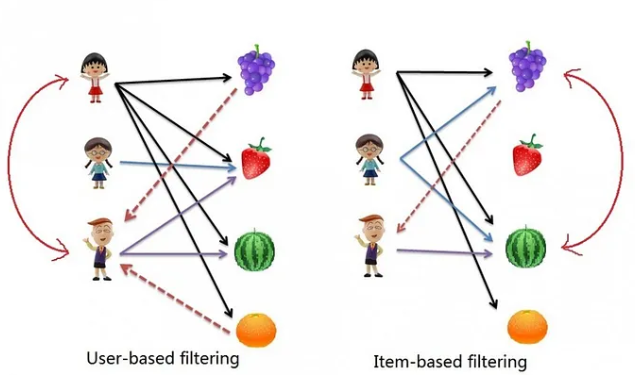

#### **User-Item Matrix**

In [ ]:
train_user_item_matrix = train_df.pivot_table(
    index='userId',
    columns='tmdbId',
    values='rating'
).fillna(0)

In [ ]:
train_user_item_matrix.T

#### **Item Similarity**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(train_user_item_matrix.T) # sklearn calculate rows by rows

item_similarity_df = pd.DataFrame(
    item_similarity,
    index= train_user_item_matrix.columns,
    columns= train_user_item_matrix.columns
)

In [ ]:
item_similarity_df.head()

**Quick Overview**
- Matrix shows how close movies are to each other.

**Score MeaningsScore**
- 1: Perfect match (identical movies)
- 0: Zero match (completely different movies).

**Example:**  High/Moderate Match (0.416799): Movie 1 & Movie 2. Similar taste profiles.


In [ ]:
def recommend_item_based(user_id, top_n=5):
    # Make sure user inside train data
    if user_id not in train_user_item_matrix.index:
          return []
    # 1. Get the user's rating vector for all movies
    user_ratings = train_user_item_matrix.loc[user_id].copy() # loc : access rows, columns by using labels name

    # 2. Identify movies already rated by the user
    watched_in_train = user_ratings[user_ratings > 0].index

    # 3. Keep only rated movies for recommendation scoring
    user_ratings[user_ratings <= 0] = 0

    # 4. Compute recommendation scores using matrix multiplication
    # User rating vector (1 x num_movies) multiplied by item similarity matrix (num_movies x num_movies)
    scores_series = item_similarity_df.dot(user_ratings)

    # 5. Remove movies already watched by the user
    scores_series = scores_series.drop(watched_in_train,errors='ignore') # skips missing labels safely.

    # 6. Remove non-positive recommendation scores
    scores_series = scores_series[scores_series > 0]

    # 7. Return Top-K highest scored movies
    if scores_series.empty:
        return []

    return scores_series.sort_values(ascending=False).head(top_n).index.tolist()


In [ ]:
item_recommendations = {}

for user_id in ground_truth.keys():
    item_recommendations[user_id] = recommend_item_based(user_id,top_n=5)


In [ ]:
item_results = evaluate_topn(item_recommendations,ground_truth,k=5)

item_evaluation_df = pd.DataFrame([item_results])
item_evaluation_df= item_evaluation_df.astype(float)

print(item_evaluation_df)

#### **Save 100% matrix for UI**

In [ ]:
user_item_matrix = ratings_clean.pivot_table(
    index='userId',
    columns='tmdbId',
    values='rating'
).fillna(0)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(user_item_matrix.T) # sklearn calculate rows by rows

item_similarity_df = pd.DataFrame(
    item_similarity,
    index= user_item_matrix.columns,
    columns= user_item_matrix.columns
)

In [ ]:
movie_ids = item_similarity_df.index.tolist()

top_k = 5
item_topk = {}

# Use .values to extract a pure NumPy array for a massive speed boost
similarity_matrix = item_similarity_df.values

for i, movie_id in enumerate(movie_ids):
    # 1. Extract the similarity scores of the current movie against all other movies
    raw_scores = similarity_matrix[i]

    # 2. Core Fix: Pair the scores with the ACTUAL movie IDs instead of sequential index positions (0, 1, 2...)
    id_score_pairs = list(zip(movie_ids, raw_scores))

    # 3. Sort the pairs in descending order based on the similarity score
    id_score_pairs_sorted = sorted(id_score_pairs, key=lambda x: x[1], reverse=True)

    # 4. Slice the Top-K matches (Skip index 0 because a movie's similarity with itself is always 1.0)
    item_topk[int(movie_id)] = id_score_pairs_sorted[1:top_k+1]

In [ ]:
# with gzip.open("item_topk.pkl.gz", "wb") as f:
#     pickle.dump(item_topk, f)

# # Downlaod to local computer
# from google.colab import files
# files.download("item_topk.pkl.gz")

### **Method 2 : SVD**

**SVD (Singular Value Decomposition)** is a recommendation technique that **predicts missing ratings by discovering hidden patterns** (latent factors) between users and movies.

In [ ]:
from surprise import Dataset, Reader, SVD

reader = Reader(rating_scale=(0.5, 5))

train_surprise = Dataset.load_from_df(
    train_df[['userId', 'tmdbId', 'rating']],
    reader
)

trainset = train_surprise.build_full_trainset()

In [ ]:
svd_model = SVD()
svd_model.fit(trainset)

In [ ]:
# 3. Cleaned Recommendation Function
def recommend_svd(user_id, model, train_user_item, all_movie_ids, top_n=5):
    """Generates Top-N recommendations for a specific user using a trained SVD model."""

    if user_id in train_user_item.index:
        user_vector = train_user_item.loc[user_id]
        watched_movies = set(user_vector[user_vector > 0].index)
    else:
        watched_movies = set()

    unwatched_movies = [movie_id for movie_id in all_movie_ids if movie_id not in watched_movies]
    # Predicting Ratings with the SVD Model
    predictions = []
    for movie_id in unwatched_movies:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    # Sorting and Extracting the Top N
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n_recommendations = [movie_id for movie_id, score in predictions[:top_n]]

    return top_n_recommendations

In [ ]:
# Extract all unique movie IDs from your training set universe
all_movie_ids = train_df['tmdbId'].unique().tolist()

svd_recommendations = {}

# Generate predictions for every user present in your evaluation ground truth
for user_id in ground_truth.keys():
    svd_recommendations[user_id] = recommend_svd(
        user_id=user_id,
        model=svd_model, # Pass your fitted surprise SVD instance
        train_user_item=train_user_item_matrix,  # Your training pivot table
        all_movie_ids=all_movie_ids,
        top_n=10
    )

# Run it through your existing evaluation engine!
svd_results = evaluate_topn(
    svd_recommendations,
    ground_truth,
    k=5
)

In [ ]:
svd_evaluation_df = pd.DataFrame([svd_results])
svd_evaluation_df= svd_evaluation_df.astype(float)

print(svd_evaluation_df)

### **Method 3 : BPR**

**Bayesian Personalized Ranking (BPR)** is a pairwise optimization framework that trains recommendation models to rank items a user has interacted with higher than items they haven't.
- Compare items in pairs, and put the preferred one first.


In [ ]:
import implicit
from scipy.sparse import csr_matrix

# =====================================================================
# 1. PREPARE THE DATA (Implicit Feedback)
# =====================================================================
# BPR treats ratings >= 3.0 as positive interactions (1), and ignores the rest.
positive_train = train_df[train_df['rating'] >= 3.5].copy()

# Map userIds and tmdbIds to clean, contiguous integer indices for mapping
positive_train['user_encoded'] = positive_train['userId'].astype('category').cat.codes
positive_train['item_encoded'] = positive_train['tmdbId'].astype('category').cat.codes

# Create lookup dictionaries to map back and forth later
user_lookup = dict(zip(positive_train['userId'], positive_train['user_encoded']))
item_lookup = dict(zip(positive_train['item_encoded'], positive_train['tmdbId']))

num_users = positive_train['user_encoded'].nunique()
num_items = positive_train['item_encoded'].nunique()

# Create a User-Item Sparse Matrix (CSR Matrix)
# Implicit feedback binary array: data is just an array of 1s representing "watched"
user_item_matrix = csr_matrix(
    (np.ones(len(positive_train)), (positive_train['user_encoded'], positive_train['item_encoded'])),
    shape=(num_users, num_items)
)

# =====================================================================
# 2. INITIALIZE AND TRAIN THE BPR MODEL
# =====================================================================
# factors: embedding dimensions (latent factors)
# learning_rate: step size for gradient descent
# regularization: L2 penalty to prevent overfitting
bpr_model = implicit.bpr.BayesianPersonalizedRanking(
    factors=64,
    learning_rate=0.05,
    regularization=0.01,
    iterations=50,
    random_state=42
)

# Train the model (expects an Item-User or User-Item sparse matrix depending on settings)
bpr_model.fit(user_item_matrix)

In [ ]:
# =====================================================================
# 3. DEFINE THE BPR RECOMMENDATION FUNCTION
# =====================================================================
def recommend_bpr(user_id, model, user_item_matrix, user_lookup, item_lookup, top_n=5):
    """
    Generates Top-N recommendations for a specific user using the trained BPR model.
    """
    # Handle Cold Start: If user wasn't in the positive training data
    if user_id not in user_lookup:
        return []

    # Get the internal index mapping for this user
    user_encoded_id = user_lookup[user_id]

    # model.recommend expects the user index and their row vector from the matrix
    # filter_already_liked_items=True completely blocks movies they already watched in train
    ids, scores = model.recommend(
        userid=user_encoded_id,
        user_items=user_item_matrix[user_encoded_id],
        N=top_n,
        filter_already_liked_items=True
    )

    # Map internal item indices back to your original tmdbIds
    top_n_recommendations = [item_lookup[item_idx] for item_idx in ids]

    return top_n_recommendations

In [ ]:
# =====================================================================
# 4. BATCH GENERATION & EVALUATION LOOP
# =====================================================================
bpr_recommendations = {}

for user_id in ground_truth.keys():
    bpr_recommendations[user_id] = recommend_bpr(
        user_id=user_id,
        model=bpr_model,
        user_item_matrix=user_item_matrix,
        user_lookup=user_lookup,
        item_lookup=item_lookup,
        top_n=5
    )

# Feed it right into your existing grading script!
bpr_results = evaluate_topn(
    bpr_recommendations,
    ground_truth,
    k=5
)

In [ ]:
bpr_evaluation_df = pd.DataFrame([bpr_results])
bpr_evaluation_df= bpr_evaluation_df.astype(float)

print(bpr_evaluation_df)

### **Comparison**

In [ ]:
comparison_df = pd.concat(
    [item_evaluation_df, svd_evaluation_df,bpr_evaluation_df],
    axis=0
)
comparison_df.index = ["Item-Based CF", "SVD", 'BPR']

comparison_df

Based On these three method, I chose **Item-Based Collaborative Filtering** for deployment because it consistently outperformed both SVD and BPR across all key evaluation metrics at `K=5`. Specifically, it achieved the highest Precision, Recall, Hit Rate, and NDCG, demonstrating superior accuracy and ranking quality for the movie recommendations.

## **Phase 2 : Content Based Filtering**

### **A) Load Dataset**

In [ ]:
tmdb = pd.read_csv('/content/drive/MyDrive/dataset/movie/API/preprocess_dataset/final_tmdb_api.csv')

In [ ]:
display(tmdb.head(1))
print(tmdb.shape)

In [ ]:
tmdb.iloc[0]

### **B) Data Checking**

After extracting movie metadata via the TMDB API **(Part A)**, some requests failed, so the dataset is now being loaded to inspect the status of each record

In [ ]:
tmdb['status'].value_counts()

In [ ]:
fail_movielens = tmdb[tmdb['status'] == 'failed']
fail_movielens

- Rows with `status = failed` and `source = movielens` indicate that the corresponding TMDB metadata is no longer available for those MovieLens entries, so these records are removed,
- Rows with `status = failed` and `source = kaggle` are retained as they only lack poster data but still contain usable movie information.

In [ ]:
tmdb = tmdb[~((tmdb['status'] == 'failed') & (tmdb['source'] == 'movielens'))]

In [ ]:
tmdb.shape

#### **Drop cache columns**

In [ ]:
tmdb = tmdb.drop(columns=['status','poster_status', 'source'])

In [ ]:
tmdb.info()

### **C) Data Preprocessing**

In [ ]:
tmdb_df = tmdb.copy()

In [ ]:
tmdb_df.head(1)

#### **- Convert nested list/dict structures into clean comma-separated strings**

In [ ]:
cols = ['genres', 'keywords', 'production_companies', 'director', 'cast']

def clean_feature(x, is_cast=False):
    if pd.isna(x):
        return np.nan

    # convert string → list if needed
    if isinstance(x, str): # Is x an instance of a string?
        try:
            x = ast.literal_eval(x)
        except:
            return np.nan

    # convert empty list → NaN
    if isinstance(x, list) and len(x) == 0:
        return np.nan

    # cast column (dict handling)
    if is_cast:
        if isinstance(x, list):
            names = []
            for i in x:
              if isinstance(i, dict):
                  names.append(i.get('name') or i.get('actor'))
            return ",".join(names) if names else np.nan
        return np.nan

    # normal list columns
    if isinstance(x, list): # Is x an instance of a list?
        return ",".join([str(i).strip() for i in x])

    return np.nan

In [ ]:
for col in cols:
    if col == 'cast':
        tmdb_df[col] = tmdb_df[col].apply(lambda x: clean_feature(x, is_cast=True))
    else:
        tmdb_df[col] = tmdb_df[col].apply(clean_feature)

In [ ]:
cols = ['tmdbId','genres', 'keywords', 'production_companies', 'director', 'cast']
tmdb_df[cols].head(1)

In [ ]:
tmdb_df.info()

In [ ]:
tmdb_df.isna().sum()

Since `genres` feature is the most important features, we can fix missing genres by checking the movie IDs with `movielens.csv` and get the correct genre data from there.

The Other features' missing values are filled with an empty string **`''`** because we do not know the true information, so we should not add any fake or assumed data.

In [ ]:
tmdb_df['genres'].isna().sum()

In [ ]:
missing_genres_df = tmdb_df[tmdb_df['genres'].isna()]
missing_genres_df

In [ ]:
# Create a dictionary of the updates
genre_updates = {
    'movie_141489': 'Drama',
    'movie_1676563': 'Action,Adventure,Fantasy',
    'movie_554191': 'Music, Mystery'
}

# Update only the rows that match the cache_key
tmdb_df.loc[tmdb_df['cache_key'].isin(genre_updates.keys()), 'genres'] = tmdb_df['cache_key'].map(genre_updates)

In [ ]:
tmdb_df['genres'].isna().sum()

#### **- Fill NaN**

In [ ]:
object_cols = tmdb_df.select_dtypes(include='object').columns

tmdb_df[object_cols] = tmdb_df[object_cols].fillna('')

In [ ]:
tmdb_df.isna().sum()

However, runtime is kept as **`NaN`** because filling it with '' would change its data type and affect numerical processing.

#### **- Check Genres Quality**

In [ ]:
# .str.split(','): Splits the string at every comma into a list of strings.
# .explode(): Flattens the lists, giving each genre its own separate row.
    # Without ".explode()" -> Action, Sci-Fi: 1 ; Action: 1
    # With ".explode()" -> Action: 2 ; Sci-Fi : 1
# .str.strip(): Trims any excess whitespace so genres match perfectly.
genre_counts = (tmdb_df['genres'].dropna().str.split(',').explode().str.strip().value_counts())
print(genre_counts)

Some genre values contained combined labels such as `"Action & Adventure"`, `"Sci-Fi & Fantasy"` and `"War & Politics"`, which would be treated as unique genres by Pandas, so the `"&"` symbol was replaced with a **comma** to separate them into individual genres

**P.S. Sci-Fi = Science Fiction, so that we need standarize it.**

In [ ]:
tmdb_df['genres'] = tmdb_df['genres'].str.replace('&', ',', regex=False).str.replace('Sci-Fi', 'Science Fiction', regex=False)

#### **- Get first 10 casts**

I limited the selection to the first 10 cast members for each movie to keep the dataset clean and filter out minor, less recognizable characters

In [ ]:
tmdb_df[tmdb_df['tmdbId'] == 143634]

In [ ]:
tmdb_df['cast'] = tmdb_df['cast'].apply(
    lambda x: ",".join(x.split(",")[:10]) if isinstance(x, str) else "")

In [ ]:
tmdb_df['cast'][0]

### **D) TF - IDF**

In [ ]:
tmdb_df.head(1)

In [ ]:
content_df = tmdb_df[['media_type','tmdbId','title','genres','production_companies','keywords','director','cast']].copy()

#### **- Remove spaces from names and add underscore**

I removed spaces from names and replaced them with underscores (for example, transforming "Tom Holland" into "Tom_Holland") because TF-IDF evaluates text word-by-word, which would otherwise cause it to wrongly assume that **"Tom Holland," "Tom Cruise," and "Tom Hanks"** are the same person based on the shared word **"Tom"**.

In [ ]:
content_df['cast'] = content_df['cast'].str.replace(' ', '_', regex=False)
content_df['director'] = content_df['director'].str.replace(' ', '_', regex=False)

In [ ]:
print(content_df['cast'][0])
print(content_df['director'][0])

In [ ]:
display(content_df.head(1))
print(content_df.shape)

#### **- Create tags column**

In [ ]:
# Repeat production_companies twice to give it double the weight
content_df['tags'] = (content_df['genres'] + ' | ' +
                      content_df['production_companies'] + ' | ' +
                      content_df['keywords'] + ' | ' +
                      content_df['director'] + ' | ' +
                      content_df['cast'])
# Replace commas with spaces
content_df['tags'] = content_df['tags'].str.replace(',', ' ')

# Convert to lowercase
content_df['tags'] = content_df['tags'].str.lower()

In [ ]:
display(content_df.head(1))

In [ ]:
content_df['tags'][0]

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer(stop_words='english')
# tfidf_matrix = tfidf.fit_transform(content_df['tags'])

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. Vectorize features separately
vec_genres_keywords = TfidfVectorizer(stop_words='english')
vec_cast_director = TfidfVectorizer(stop_words='english')
vec_studio = TfidfVectorizer(stop_words='english')

matrix_gk = vec_genres_keywords.fit_transform(content_df['genres'] + ' ' + content_df['keywords'])
matrix_cd = vec_cast_director.fit_transform(content_df['director'] + ' ' + content_df['cast'])
matrix_s = vec_studio.fit_transform(content_df['production_companies'])

# 2. Apply smart weights (Adjust these numbers to tune your system)
# We give Genres/Keywords the highest weight, followed by creators, then studio.
matrix_final = hstack([
    matrix_gk * 1.5,  # Highest priority: What the movie is actually about
    matrix_cd * 1.3,  # High priority: Who made it and who stars in it
    matrix_s * 1.2    # Medium priority: The studio brand
])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(matrix_final)

#### **- Sanity check**

Content-based filtering was evaluated using **sanity checks** rather than **Top-K ranking metrics** because it measures similarity based on item attributes such as genres, keywords, and metadata rather than predicting user preferences from historical interactions.

The quality of recommendations was assessed by examining whether the retrieved movies were meaningfully related to the selected movie based on their content features.

In [ ]:
def recommend(movie_title, top_n=10):
    idx = content_df[content_df['title'] == movie_title].index[0]
    sim_scores = list(enumerate(similarity[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    top_movies = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in top_movies]
    scores = [round(i[1], 4) for i in top_movies]

    result = content_df.iloc[movie_indices][[
        'title',
        'genres',
        'production_companies',
        'director',
        'cast'
    ]].copy()

    result['score'] = scores

    return result

In [ ]:
recommend("Harry Potter and the Philosopher's Stone")

In [ ]:
recommend("The Dark Knight")

In [ ]:
recommend("Toy Story 3")

#### **- Save top 10 results for each movie**

In [ ]:
# 1. Get the list of ACTUAL movie IDs in the exact order of your matrix rows
# (Change 'tmdbId' to 'movieId' if you are using MovieLens IDs at this stage)
movie_ids = content_df['tmdbId'].tolist()

top_k = 10
top_k_sim = {}

# Convert your similarity matrix to a NumPy array (.values) for a huge speed boost
similarity_matrix = similarity.values if hasattr(similarity, 'values') else similarity

for i, current_movie_id in enumerate(movie_ids):
    # Get all similarity scores for the current movie
    sim_scores = similarity_matrix[i]

    # Pair scores with REAL movie IDs instead of row numbers (0, 1, 2...)
    id_score_pairs = list(zip(movie_ids, sim_scores))

    # Sort by similarity score in descending order
    id_score_pairs_sorted = sorted(id_score_pairs, key=lambda x: x[1], reverse=True)

    # Slice the top K matches (skipping index 0 to exclude itself)
    # Force the key to be a standard integer to prevent float formatting issues
    top_k_sim[int(current_movie_id)] = id_score_pairs_sorted[1:top_k+1]

In [ ]:
# # Save to local computer
# with gzip.open("tfidf_topk.pkl.gz", "wb") as f:
#     pickle.dump(top_k_sim, f)

# from google.colab import files
# files.download("tfidf_topk.pkl.gz")


## **Phase 3 : NLP Based Filtering**

In [ ]:
tmdb_df.head(1)

In [ ]:
nlp_df = tmdb_df[['media_type','tmdbId','title','genres','overview','keywords','production_companies','director','cast']].copy()
nlp_df.head(1)

In [ ]:
nlp_df.isna().sum()

#### **- Create Tag Columns**

In [ ]:
nlp_df['tags'] = (
    "A movie titled '" + nlp_df['title'] + "'. " +
    "Genres: " + nlp_df['genres'] + ". " +
    "Plot Overview: " + nlp_df['overview'] + " " +
    "Key themes and elements: " + nlp_df['keywords'] + ". " +  "Production Companies: " + nlp_df['production_companies'] + "."+
    "Directed by " + nlp_df['director'] + " and starring " + nlp_df['cast']
)

In [ ]:
nlp_df['tags'][0]

In [ ]:
nlp_df.shape

#### **SBERT (Sentence-BERT)**

SBERT leverages these dense vector embeddings to compare user search queries directly against movie tags, enabling deep, context-aware semantic recommendations that capture the true intent behind natural language.

In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
# embeddings = model.encode(nlp_df['tags'].tolist(), show_progress_bar=True)

#### **Embeddings**

In [ ]:
# # Save to Local Computer
# with gzip.open("sbert_embeddings.pkl.gz", "wb") as f:
#     pickle.dump(embeddings, f)

# # Downlaod to local computer
# from google.colab import files
# files.download("sbert_embeddings.pkl.gz")


# # Google Drive Function
# file_path = "/content/drive/MyDrive/dataset/movie/Streamlit/sbert_embeddings.pkl.gz"
# with gzip.open(file_path, "wb") as f:
#     pickle.dump(embeddings, f)

# print(f"Success! Embeddings saved directly to Drive at: {file_path}")

In [ ]:
# Correct way to load your compressed SBERT embeddings
file_path = "/content/drive/MyDrive/dataset/movie/Streamlit/sbert_embeddings.pkl.gz"

with gzip.open(file_path, "rb") as f:
    embeddings = pickle.load(f)

print("Embeddings loaded successfully!")

In [ ]:
embeddings

#### **Semantic search engine**

##### **Method 1 : BI encoder**

In [ ]:
# Bi Encoder only
def search_movies(query, top_k=10):
    # 1. Encode the user query into the vector space
    query_vec = model.encode([query])

    # 2. Compute cosine similarity scores across your entire embedding matrix
    scores = cosine_similarity(query_vec, embeddings)[0]

    # 3. Sort indices from highest similarity score to lowest
    top_indices = np.argsort(scores)[::-1][:top_k]

    # 4. Extract target data and attach the calculated match confidence score
    result = nlp_df.iloc[top_indices][["title", "genres", "overview"]].copy()
    result['match_score'] = [round(scores[idx], 4) for idx in top_indices]

    return result

##### **Method 2 : Bi Encoder + Cross Encoder**

In [ ]:
# Cross Encoder
from sentence_transformers import CrossEncoder

# Load a highly optimized re-ranking model
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def advanced_search_movies(query, top_k=10):
    # Clean the query for strict keyword checking
    clean_query = query.strip().lower()

  # STEP 1:  Keyword Interception (For short queries like "nolan")
    # Check if the query matches a director, part of a title, or a main actor
    keyword_matches = nlp_df[
        (nlp_df['director'].str.lower().str.contains(clean_query)) |
        (nlp_df['title'].str.lower().str.contains(clean_query)) |
        (nlp_df['cast'].str.lower().str.contains(clean_query))|
        (nlp_df['production_companies'].str.lower().str.contains(clean_query))
    ]

    # If the user typed a short keyword and we found direct text matches, return them instantly!
    if len(clean_query.split()) <= 3 and not keyword_matches.empty:
        # Sort them by popularity or vote average so the best ones show first
        result = keyword_matches.sort_values(by='popularity', ascending=False).head(top_k)
        # Add a dummy score column so downstream UI layout doesn't break
        result['rerank_score'] = 99.0
        return result[["title", "genres", "overview", "rerank_score"]]

    # STEP 2: SEMANTIC AI FALLBACK (For long descriptions like "movie about space travel")
    # If it's a long sentence description, use the deep Cross-Encoder model
    query_vec = model.encode([query])
    scores = cosine_similarity(query_vec, embeddings)[0]
    candidate_indices = np.argsort(scores)[::-1][:30]

    candidates = nlp_df.iloc[candidate_indices].copy()

    pairs = [[query, row['tags']] for _, row in candidates.iterrows()]
    cross_scores = cross_encoder.predict(pairs)
    candidates['rerank_score'] = cross_scores

    final_sorted = candidates.sort_values(by='rerank_score', ascending=False).head(top_k)
    return final_sorted[["title", "genres", "overview", "rerank_score"]]

##### **Evaluation (Sanity Check)**

###### - Harry Potter

In [ ]:
search_movies("fantasy movies featuring a school of witchcraft and wizardry called Hogwarts")

In [ ]:
advanced_search_movies("fantasy movies featuring a school of witchcraft and wizardry called Hogwarts")


###### - Finding Nemo


In [ ]:
search_movies("movies by pixar and include fish")

In [ ]:
advanced_search_movies("movies by pixar and include fish")

Based on the results above, we can see that function "advanced_search_movies" have more accurate compare to "search_movies". So I use it as my deployment

##### **Save to local files computer**

In [ ]:
tmdb_df['nlp_tags'] = nlp_df['tags']

In [ ]:
# tmdb_df.to_csv("tmdb_clean.csv", index=False)

# # Save files to local computer
# from google.colab import files
# files.download("tmdb_clean.csv")